
El dataset con el que vamos a trabajar en este notebook contiene un total de **426 Series Temporales** que abarcan el periodo Enero'2013 - Septiembre'2015. Por tanto vamos a trabajar con **Series Temporales Multivariante**.

Cada una de estas **Series Temporales** representan las ventas <u>**MENSUALES**</u> de **un artículo en un tienda y ciudad**. El objetivo es predecir las <u>**VENTAS TOTALES DEL MES DE OCTUBRE'2015**</u>.



<a id='index'></a>
### Índice

[Imports del notebook](#imports_notebook)<br>
[Data Loading](#data_load)<br>
[La idea del Benchmark (**CORE IDEA**)](#benchmark)<br>
[Data Imputation](#impute)<br>
[EDA](#eda)<br>
[--> 1. EDA: Global Sales](#eda_global_sales)<br>
[--> 2. EDA: Top 3 Cities](#eda_top_3_cities)<br>
[--> 3. EDA: Top 3 Categories](#eda_top_3_categories)<br>
[Build Time Series Features (**CORE IDEA**)](#build_ts_features)<br>
[Join TS Features](#join_ts_features)<br>
[Train Test Split](#train_test_split)<br>
[Model Train](#model_train)<br>
[Model Evaluation (**COREA IDEA**)](#model_evaluation)<br>
[Prediction](#prediction)<br>

### Conclusión
[Conclusión](#conclusion)<br>

### Referencias
[Referencias y lecturas recomendables](#referencias)<br>

<a id='imports_notebook'></a>
### Imports del notebook
[Volver al índice](#index)

En este apartado hacemos los principales imports del notebook.<br>
Sobre todo vamos a trabajar con **numpy**, **pandas**, **statsmodels** y **XGBoost**.

In [ ]:
import os

import pandas as pd
import xgboost as xgb

In [ ]:
print(f"pandas version: {pd.__version__}")
print(f"xgboost version: {xgb.__version__}")

pandas version: 2.2.2
xgboost version: 2.1.3


In [ ]:
# if pd.__version__ != "1.5.1":
#     os.system("pip install pandas==1.5.1")

In [ ]:
# if xgb.__version__ != "1.3.3":
#     os.system("pip install xgboost==1.3.3")

In [ ]:
import pickle
import os

from datetime import datetime
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OrdinalEncoder

import xgboost as xgb

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
print("Working with these versions of libraries\n")
print("-"*50)
print(f"Numpy version {np.__version__}")
print(f"Pandas version {pd.__version__}")
print(f"XGBoost version {xgb.__version__}")

Working with these versions of libraries

--------------------------------------------------
Numpy version 1.26.4
Pandas version 2.2.2
XGBoost version 2.1.3


In [ ]:


# DATA_PATH = ""


TRAIN_CSV_PATH = '/content/ts_kaggle_train.csv'

<a id='data_load'></a>
### Data Loading
[Volver al índice](#index)

Vamos a cargar nuestro dataset para comenzar con el EDA.

In [ ]:
df = pd.read_csv(TRAIN_CSV_PATH, index_col = 0)
df.sample(5)

,date,unique_id,city_id,shop_id,item_category_id,item_id,monthly_average_price,monthly_sales
13064,2014-01-31,58_6497,22,58,28,6497,999.000000,3.0
7813,2015-05-31,31_2574,7,31,55,2574,449.000000,7.0
805,2013-06-30,16_20949,4,16,71,20949,5.000000,30.0
13236,2015-02-28,58_12134,22,58,30,12134,365.666667,16.0
274,2013-07-31,14_20949,3,14,71,20949,5.000000,30.0


Vamos a ver que tipo de datos tenemos en nuestro dataset.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14484 entries, 0 to 14483
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   14484 non-null  object 
 1   unique_id              14484 non-null  object 
 2   city_id                14484 non-null  int64  
 3   shop_id                14484 non-null  int64  
 4   item_category_id       14484 non-null  int64  
 5   item_id                14484 non-null  int64  
 6   monthly_average_price  13262 non-null  float64
 7   monthly_sales          13756 non-null  float64
dtypes: float64(2), int64(4), object(2)
memory usage: 1018.4+ KB


In [ ]:
df["date"] = pd.to_datetime(df["date"], format = "%Y-%m-%d")

<a id='benchmark'></a>
### La idea del Benchmark (CORE IDEA)
[Volver al índice](#index)

En el presente notebook buscamos establecer un benchmark rápido.

El motivo fundamental es porque los datasets en la vida real son muy complejos y no tenemos el "lujo" de poder analizar todas y cada una de las variables <u>**ANTES DE ENTRENAR NUESTRO PRIMER MODELO.</u>**

Establecer un benchmark nos ayuda a entender cual es el punto de partida, es decir: <u>**cual es el score mínimo para este dataset.**</u>

Muchas veces este benchmark puede ser un modelo entrenado con unas pocas columnas númericas (imputando los nulos con la media). <u>**No se trata de tener el mejor modelo sino de entrenar nuestro primer modelo.**</u>

Una vez sabemos cual es el punto de partida y tenemos un notebook **"funcional"** podemos empezar a experimentar con nuestro dataset. Por **"notebook funcional"** entendemos un script/notebook que podemos ejecutar en su totalidad (loading del dataset, preprocessing, train_test_split, train y predict). En cada experimento iremos añadiendo nuevas variables, diferentes imputaciones, modelos y vamos guardando el score que obtenemos. De este manera, podemos ver la contribución de cada variables y comprobar si estamos mejorando o no respecto al benchmark.

Dado que este notebook es un benchmark, tenemos que **"acotar"** muy bien las cosas que vamos a implementar (para no irnos por las ramas).

A **grosso modo** vamos a hacer las siguientes cosas:

1. Tratar los nulos.
1. Realizar un pequeño EDA sobre el dataset.
1. Crear algunas variables rápidas para el entrenamiento.
1. Entrenar el algoritmo.
1. Evaluar el modelo.
1. Hacer el submit a Kaggle.

Empecemos:

Tenemos un total de 426 Series Temporales en el dataset:

In [ ]:
df["unique_id"].nunique()

426

Veamos cuales son las fechas min y max de nuestro dataset:

In [ ]:
MIN_DATE = df["date"].min()
MAX_DATE = df["date"].max()

In [ ]:
print(f"Min date is {MIN_DATE}\nMax date is {MAX_DATE}")

Min date is 2013-01-31 00:00:00
Max date is 2015-10-31 00:00:00


#date fix

In [ ]:
#drop row of 2015-10-31
#store row -1 into a new df
#df_last_row = df.iloc[[-1]]
#df = df[df["date"] < "2015-10-31"]


In [ ]:
MIN_DATE = df["date"].min()
MAX_DATE = df["date"].max()
print(f"Min date is {MIN_DATE}\nMax date is {MAX_DATE}")

Min date is 2013-01-31 00:00:00
Max date is 2015-10-31 00:00:00


In [ ]:
df.columns

Index(['date', 'unique_id', 'city_id', 'shop_id', 'item_category_id',
       'item_id', 'monthly_average_price', 'monthly_sales'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
date,0
unique_id,0
city_id,0
shop_id,0
item_category_id,0
item_id,0
monthly_average_price,1222
monthly_sales,728


<a id='impute'></a>
### Data Imputation
[Volver al índice](#index)<br>

In [ ]:
sample_ts = "31_4249"

In [ ]:
df[df["unique_id"] == sample_ts]

,date,unique_id,city_id,shop_id,item_category_id,item_id,monthly_average_price,monthly_sales
5666,2013-01-31,31_4249,7,31,23,4249,1899.000000,2.0
5743,2013-02-28,31_4249,7,31,23,4249,1599.000000,5.0
5820,2013-03-31,31_4249,7,31,23,4249,1013.416000,6.0
5897,2013-04-30,31_4249,7,31,23,4249,1598.900000,10.0
5974,2013-05-31,31_4249,7,31,23,4249,1598.937500,8.0
6051,2013-06-30,31_4249,7,31,23,4249,1599.000000,4.0
6128,2013-07-31,31_4249,7,31,23,4249,1399.000000,4.0
6205,2013-08-31,31_4249,7,31,23,4249,1599.000000,2.0
6282,2013-09-30,31_4249,7,31,23,4249,1199.000000,5.0
6359,2013-10-31,31_4249,7,31,23,4249,929.075000,4.0


In [ ]:
df.fillna({"monthly_sales":0}, inplace = True)

In [ ]:
df["monthly_average_price"] = df.groupby("unique_id", group_keys = False)["monthly_average_price"].apply(
    lambda series: series.bfill().ffill()
)

In [ ]:
df.isnull().sum()

,0
date,0
unique_id,0
city_id,0
shop_id,0
item_category_id,0
item_id,0
monthly_average_price,0
monthly_sales,0


In [ ]:
df.sort_values(["unique_id", "date"], ascending = True, inplace = True)

In [ ]:
df[df["unique_id"] == sample_ts]

,date,unique_id,city_id,shop_id,item_category_id,item_id,monthly_average_price,monthly_sales
5666,2013-01-31,31_4249,7,31,23,4249,1899.000000,2.0
5743,2013-02-28,31_4249,7,31,23,4249,1599.000000,5.0
5820,2013-03-31,31_4249,7,31,23,4249,1013.416000,6.0
5897,2013-04-30,31_4249,7,31,23,4249,1598.900000,10.0
5974,2013-05-31,31_4249,7,31,23,4249,1598.937500,8.0
6051,2013-06-30,31_4249,7,31,23,4249,1599.000000,4.0
6128,2013-07-31,31_4249,7,31,23,4249,1399.000000,4.0
6205,2013-08-31,31_4249,7,31,23,4249,1599.000000,2.0
6282,2013-09-30,31_4249,7,31,23,4249,1199.000000,5.0
6359,2013-10-31,31_4249,7,31,23,4249,929.075000,4.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14484 entries, 0 to 14483
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   14484 non-null  datetime64[ns]
 1   unique_id              14484 non-null  object        
 2   city_id                14484 non-null  int64         
 3   shop_id                14484 non-null  int64         
 4   item_category_id       14484 non-null  int64         
 5   item_id                14484 non-null  int64         
 6   monthly_average_price  14484 non-null  float64       
 7   monthly_sales          14484 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(1)
memory usage: 1018.4+ KB


In [ ]:
df.isnull().sum()

,0
date,0
unique_id,0
city_id,0
shop_id,0
item_category_id,0
item_id,0
monthly_average_price,0
monthly_sales,0


In [ ]:
df

,date,unique_id,city_id,shop_id,item_category_id,item_id,monthly_average_price,monthly_sales
0,2013-01-31,12_11365,16,12,9,11365,1511.512626,30.0
7,2013-02-28,12_11365,16,12,9,11365,1533.125000,27.0
14,2013-03-31,12_11365,16,12,9,11365,3252.470238,30.0
21,2013-04-30,12_11365,16,12,9,11365,1590.515152,27.0
28,2013-05-31,12_11365,16,12,9,11365,1447.531250,30.0
...,...,...,...,...,...,...,...,...
14435,2015-06-30,7_7893,21,7,6,7893,2490.000000,1.0
14447,2015-07-31,7_7893,21,7,6,7893,2690.000000,1.0
14459,2015-08-31,7_7893,21,7,6,7893,2490.000000,1.0
14471,2015-09-30,7_7893,21,7,6,7893,2689.900000,5.0


<a id='eda'></a>
### EDA
[Volver al índice](#index)<br>

Vamos a hacer un EDA rápido para ver como son nuestras Series Temporales y coger algunas ideas para futuras variables que vamos a implementar.

Al tratarse este notebook del benchmark, vamos a explorar de manera muy superficial el dataset. En posteriores ejecuciones analizaremos el dataset en más detalle, construiremos nuevas variables y volveremos a entrenar nuestro modelo.

<a id='eda_global_sales'></a>
### --> 1. EDA: Global Sales
[Volver al índice](#index)<br>

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14484 entries, 0 to 14483
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   14484 non-null  datetime64[ns]
 1   unique_id              14484 non-null  object        
 2   city_id                14484 non-null  int64         
 3   shop_id                14484 non-null  int64         
 4   item_category_id       14484 non-null  int64         
 5   item_id                14484 non-null  int64         
 6   monthly_average_price  14484 non-null  float64       
 7   monthly_sales          14484 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(1)
memory usage: 1018.4+ KB


In [ ]:
def plot_ts_acf_pacf(y, title):
    '''
    Plots the ts you pass and the acf and pacf.
    '''
    fig = plt.figure(figsize = (12, 10))
    ax1, ax2, ax3 = fig.subplots(3, 1)

    ax1.plot(y)
    plot_acf(x = y, ax = ax2, lags = 14)
    plot_pacf(x = y, ax = ax3, lags = 14)

    plt.suptitle(t = title, fontsize = 20)

In [ ]:
y = df.set_index("date").resample("M")["monthly_sales"].sum()[:-1] # quitamos los registros de octubre

<ipython-input-500-16f16de67f7a>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  y = df.set_index("date").resample("M")["monthly_sales"].sum()[:-1] # quitamos los registros de octubre


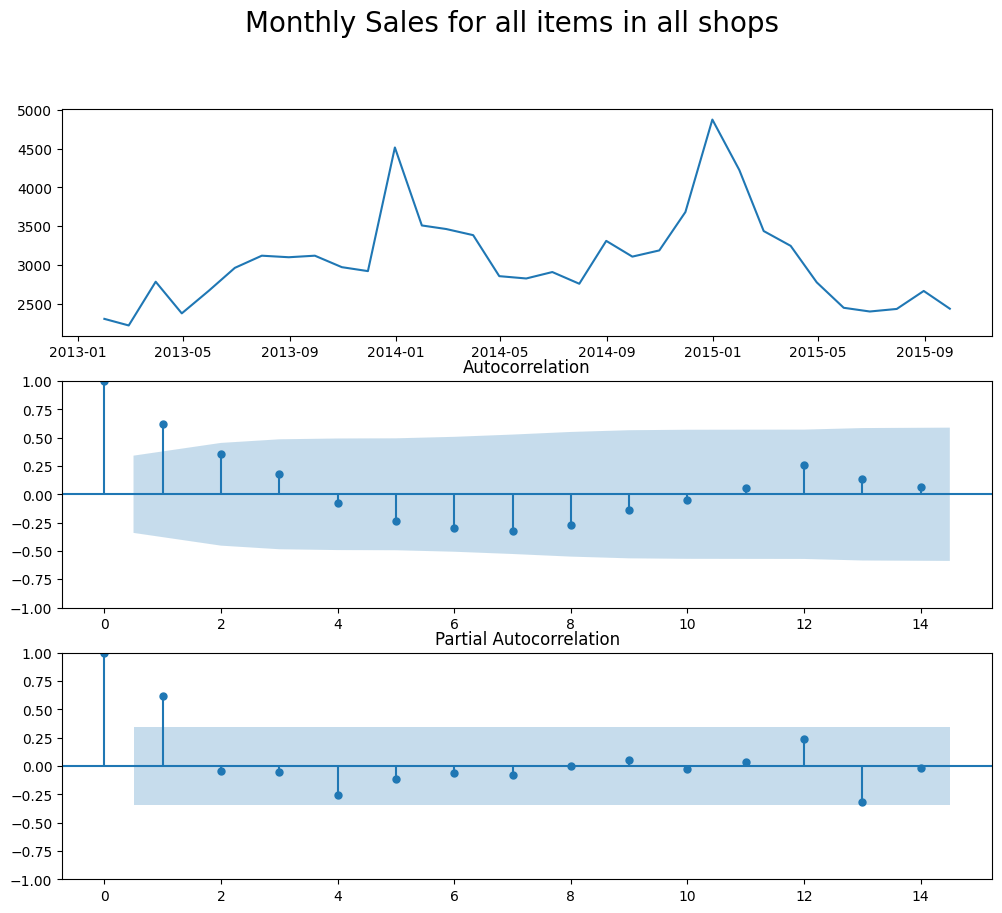

In [ ]:
plot_ts_acf_pacf(y = y, title = "Monthly Sales for all items in all shops");

Nota importante: nos estamos ayudando del gráfico de acf y pacf, pero no vamos a entrenar un modelo ARIMA.

Para resolver el problema que se nos plantea: más de 400 Series Temporales diferentes tendríamos que entrenar 400 ARIMAs (1 modelo por Serie Temporal). En cambio, con el algoritmo de XGBoost podríamos entrenar 1 único modelo.

Ahora bien, al contrario que ARIMA (que internamente construye las variables necesarias), para XGBoost debemos ser explícitos y suministrarle todas y cada una de las variables necesarias.

Del gráfico anterior ya podemos observar que las variables de lags pueden ser muy relevantes.

IDEA para los alumnos: podéis intentar analizar algunas de las 400 Series Temporales de manera individual para ver su comportamiento.

<a id='eda_top_3_cities'></a>
### --> 2. EDA: Top 3 Cities
[Volver al índice](#index)<br>

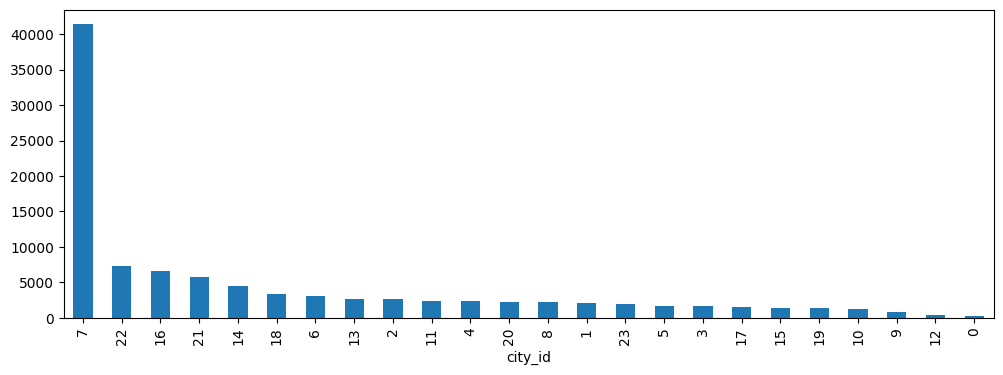

In [ ]:
(
    df.
    groupby(["city_id"])
    ["monthly_sales"].sum()
    .sort_values(ascending = False)
    .plot(kind = "bar", figsize = (12, 4))
);

<a id='eda_top_3_categories'></a>
### --> 3. EDA: Top 3 Categories
[Volver al índice](#index)<br>

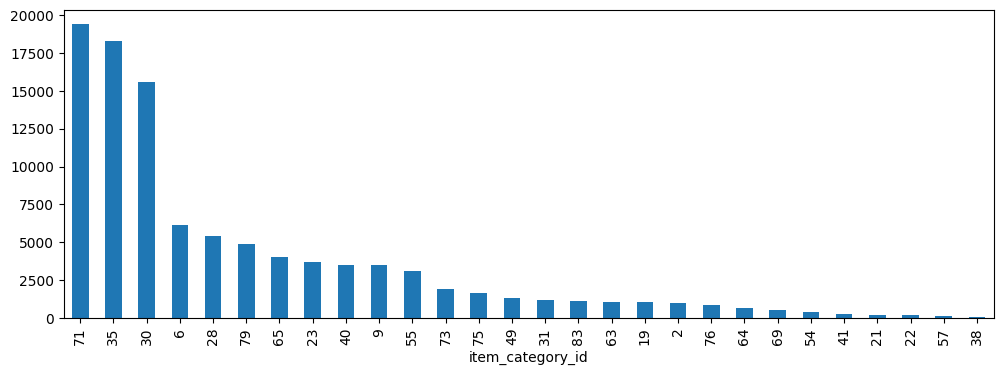

In [ ]:
(
    df.
    groupby(["item_category_id"])
    ["monthly_sales"].sum()
    .sort_values(ascending = False)
    .plot(kind = "bar", figsize = (12, 4))
);

In [ ]:
#df = df[df["date"] < "2015-10-01"]  # Remove October before feature engineering


In [ ]:
## cardinal values city,shop,item,categorty

#cardinal encoder for city taking into account the value of cardinal encoder should represent each city sales volume, so heaviest value == city with highest sales


In [ ]:
df.tail()

,date,unique_id,city_id,shop_id,item_category_id,item_id,monthly_average_price,monthly_sales
14435,2015-06-30,7_7893,21,7,6,7893,2490.0,1.0
14447,2015-07-31,7_7893,21,7,6,7893,2690.0,1.0
14459,2015-08-31,7_7893,21,7,6,7893,2490.0,1.0
14471,2015-09-30,7_7893,21,7,6,7893,2689.9,5.0
14483,2015-10-31,7_7893,21,7,6,7893,2689.9,0.0


In [ ]:
!pip install category_encoders
import category_encoders as ce

# adjust sales so that encoder doesnt take october nito account



# Step 1: Define the Target Encoder
target_encoder = ce.TargetEncoder(cols=["city_id"])
target_encoder = ce.TargetEncoder(cols=["item_id"])
target_encoder = ce.TargetEncoder(cols=["item_category_id"])
target_encoder = ce.TargetEncoder(cols=["shop_id"])

# Step 2: Fit the Encoder on city_id using monthly_sales as the target
#df["city_id_encoded"] = target_encoder.fit_transform(df["city_id"], df["monthly_sales"])

<a id='build_ts_features'></a>
### Build Time Series Features (**CORE IDEA**)
[Volver al índice](#index)<br>

Dado que vamos a tener que iterar muchas veces sobre nuestro dataset, nos interesa tener todo el código encapsulado en funciones para su reutilización.

Uno de los apartados clave será la generación de variables.

Como hemos visto antes, nuestro dataset contiene más de 400 Series Temporales.

Algunas de estas Series Temporales las podemos agrupar para sacar nueva información.

Por ejemplo, podemos construir una variables del estilo:

1. Las ventas totales por ITEM_ID (la menor granularidad posible).
2. Las ventas totales por ITEM_CATEGORY_ID y SHOP_ID (una granularidad mayor a la 1).
3. Las ventas totales por SHOP_ID (una granularidad mayor).
4. Y todas las combinaciones que queramos intermedias.

In [ ]:
df["revenue"] = df["monthly_average_price"] * df["monthly_sales"]

In [ ]:
def build_ts_vars(df, gb_list, target_column, agg_func, agg_func_name, nr_lags):

    assert "date" in df.columns.tolist(), "Date must be in df columns"

    new_name = "_".join(gb_list + [target_column] + [agg_func_name])

    gb_df_ = (
        df
        .set_index("date")
        .groupby(gb_list)
        .resample("M")[target_column]
        .apply(agg_func)
        .to_frame()
        .reset_index()
        .rename(
            columns = {
                target_column : new_name
            }
        )
    )

    for lag in range(nr_lags):
        gb_df_[f"{new_name}_lag{lag + 1}"] = gb_df_.groupby(gb_list)[new_name].transform(
            lambda series: series.shift(lag + 1)
        )

    print(f"Dropping columns that might cause target leakage {new_name}")
    gb_df_.drop(new_name, inplace = True, axis = 1)

    return gb_df_

In [ ]:
df.columns

Index(['date', 'unique_id', 'city_id', 'shop_id', 'item_category_id',
       'item_id', 'monthly_average_price', 'monthly_sales', 'revenue'],
      dtype='object')

In [ ]:
#city_id sales
vars_city_id = build_ts_vars(
    df = df,
    gb_list = ["city_id"],
    target_column = "monthly_sales",
    agg_func = np.sum,
    agg_func_name =  "sum",
    nr_lags = 3
)

Dropping columns that might cause target leakage city_id_monthly_sales_sum


<ipython-input-512-5d62409baf24>:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")[target_column]
<ipython-input-512-5d62409baf24>:12: FutureWarning: The provided callable <function sum at 0x7e90d691ca40> is currently using DatetimeIndexResamplerGroupby.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .apply(agg_func)


In [ ]:
#item_category_id sales
vars_item_category_id = build_ts_vars(
    df = df,
    gb_list = ["item_category_id"],
    target_column = "monthly_sales",
    agg_func = np.sum,
    agg_func_name =  "sum",
    nr_lags = 3

)

Dropping columns that might cause target leakage item_category_id_monthly_sales_sum


<ipython-input-512-5d62409baf24>:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")[target_column]
<ipython-input-512-5d62409baf24>:12: FutureWarning: The provided callable <function sum at 0x7e90d691ca40> is currently using DatetimeIndexResamplerGroupby.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .apply(agg_func)


In [ ]:

#original
vars_item_id = build_ts_vars(
    df = df,
    gb_list = ["item_id"],
    target_column = "monthly_sales",
    agg_func = np.sum,
    agg_func_name =  "sum",
    nr_lags = 3

)
#original
vars_shop_item_revenue = build_ts_vars(
    df = df,
    gb_list = ["shop_id", "item_id"],
    target_column = "revenue",
    agg_func = np.sum,
    agg_func_name =  "sum",
    nr_lags = 3

)

<ipython-input-512-5d62409baf24>:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")[target_column]
<ipython-input-512-5d62409baf24>:12: FutureWarning: The provided callable <function sum at 0x7e90d691ca40> is currently using DatetimeIndexResamplerGroupby.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .apply(agg_func)


Dropping columns that might cause target leakage item_id_monthly_sales_sum


<ipython-input-512-5d62409baf24>:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")[target_column]
<ipython-input-512-5d62409baf24>:12: FutureWarning: The provided callable <function sum at 0x7e90d691ca40> is currently using DatetimeIndexResamplerGroupby.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .apply(agg_func)


Dropping columns that might cause target leakage shop_id_item_id_revenue_sum


In [ ]:
df.columns

Index(['date', 'unique_id', 'city_id', 'shop_id', 'item_category_id',
       'item_id', 'monthly_average_price', 'monthly_sales', 'revenue'],
      dtype='object')

In [ ]:
vars_shop_item_revenue

,shop_id,item_id,date,shop_id_item_id_revenue_sum_lag1,shop_id_item_id_revenue_sum_lag2,shop_id_item_id_revenue_sum_lag3
0,3,5822,2013-01-31,NaN,NaN,NaN
1,3,5822,2013-02-28,999.0,NaN,NaN
2,3,5822,2013-03-31,999.0,999.0,NaN
3,3,5822,2013-04-30,1049.0,999.0,999.0
4,3,5822,2013-05-31,1048.5,1049.0,999.0
...,...,...,...,...,...,...
14479,59,22088,2015-06-30,357.0,357.0,476.0
14480,59,22088,2015-07-31,476.0,357.0,357.0
14481,59,22088,2015-08-31,833.0,476.0,357.0
14482,59,22088,2015-09-30,833.0,833.0,476.0


<a id='join_ts_features'></a>
### Join TS Features
[Volver al índice](#index)<br>

En este apartado, hacemos el merge del full_df con las variables auxiliares.

Debemos controlar muy bien el merge, para no provocar un cartesiano.

In [ ]:
df.head()

,date,unique_id,city_id,shop_id,item_category_id,item_id,monthly_average_price,monthly_sales,revenue
0,2013-01-31,12_11365,16,12,9,11365,1511.512626,30.0,45345.378788
7,2013-02-28,12_11365,16,12,9,11365,1533.125000,27.0,41394.375000
14,2013-03-31,12_11365,16,12,9,11365,3252.470238,30.0,97574.107143
21,2013-04-30,12_11365,16,12,9,11365,1590.515152,27.0,42943.909091
28,2013-05-31,12_11365,16,12,9,11365,1447.531250,30.0,43425.937500


In [ ]:
print(df.shape)

df = pd.merge(df, vars_item_id, on = ["date", "item_id"], how = "left")
df = pd.merge(df, vars_city_id, on = ["date", "city_id"], how = "left")

df = pd.merge(df, vars_item_category_id, on = ["date", "item_category_id"], how = "left")
df = pd.merge(df, vars_shop_item_revenue, on = ["date", "shop_id", "item_id"], how = "left")#df = pd.merge(df, vars_shop_city_id_revenue, on = ["date", "city_id", "shop_id"], how = "left")


#
print(df.shape)

(14484, 9)
(14484, 21)


In [ ]:
df.columns

Index(['date', 'unique_id', 'city_id', 'shop_id', 'item_category_id',
       'item_id', 'monthly_average_price', 'monthly_sales', 'revenue',
       'item_id_monthly_sales_sum_lag1', 'item_id_monthly_sales_sum_lag2',
       'item_id_monthly_sales_sum_lag3', 'city_id_monthly_sales_sum_lag1',
       'city_id_monthly_sales_sum_lag2', 'city_id_monthly_sales_sum_lag3',
       'item_category_id_monthly_sales_sum_lag1',
       'item_category_id_monthly_sales_sum_lag2',
       'item_category_id_monthly_sales_sum_lag3',
       'shop_id_item_id_revenue_sum_lag1', 'shop_id_item_id_revenue_sum_lag2',
       'shop_id_item_id_revenue_sum_lag3'],
      dtype='object')

# ENTRENAMOS SIEMPRE CON EL PASADO

In [ ]:
df.tail()

,date,unique_id,city_id,shop_id,item_category_id,item_id,monthly_average_price,monthly_sales,revenue,item_id_monthly_sales_sum_lag1,...,item_id_monthly_sales_sum_lag3,city_id_monthly_sales_sum_lag1,city_id_monthly_sales_sum_lag2,city_id_monthly_sales_sum_lag3,item_category_id_monthly_sales_sum_lag1,item_category_id_monthly_sales_sum_lag2,item_category_id_monthly_sales_sum_lag3,shop_id_item_id_revenue_sum_lag1,shop_id_item_id_revenue_sum_lag2,shop_id_item_id_revenue_sum_lag3
14479,2015-06-30,7_7893,21,7,6,7893,2490.0,1.0,2490.0,28.0,...,40.0,147.0,193.0,220.0,91.0,95.0,107.0,8520.0,5780.0,11826.666667
14480,2015-07-31,7_7893,21,7,6,7893,2690.0,1.0,2690.0,43.0,...,28.0,173.0,147.0,193.0,117.0,91.0,95.0,2490.0,8520.0,5780.000000
14481,2015-08-31,7_7893,21,7,6,7893,2490.0,1.0,2490.0,37.0,...,28.0,147.0,173.0,147.0,102.0,117.0,91.0,2690.0,2490.0,8520.000000
14482,2015-09-30,7_7893,21,7,6,7893,2689.9,5.0,13449.5,38.0,...,43.0,178.0,147.0,173.0,108.0,102.0,117.0,2490.0,2690.0,2490.000000
14483,2015-10-31,7_7893,21,7,6,7893,2689.9,0.0,0.0,38.0,...,37.0,160.0,178.0,147.0,98.0,108.0,102.0,13449.5,2490.0,2690.000000


<a id='train_test_split'></a>
### Train Test Split
[Volver al índice](#index)<br>

In [ ]:
df.columns.tolist()

['date',
 'unique_id',
 'city_id',
 'shop_id',
 'item_category_id',
 'item_id',
 'monthly_average_price',
 'monthly_sales',
 'revenue',
 'item_id_monthly_sales_sum_lag1',
 'item_id_monthly_sales_sum_lag2',
 'item_id_monthly_sales_sum_lag3',
 'city_id_monthly_sales_sum_lag1',
 'city_id_monthly_sales_sum_lag2',
 'city_id_monthly_sales_sum_lag3',
 'item_category_id_monthly_sales_sum_lag1',
 'item_category_id_monthly_sales_sum_lag2',
 'item_category_id_monthly_sales_sum_lag3',
 'shop_id_item_id_revenue_sum_lag1',
 'shop_id_item_id_revenue_sum_lag2',
 'shop_id_item_id_revenue_sum_lag3']

In [ ]:

COLUMNS_TO_DROP = [
    "revenue"
]

df.drop(COLUMNS_TO_DROP, inplace = True, axis = 1)


In [ ]:
df.set_index("unique_id", inplace = True)

In [ ]:
df.sample(5)

,date,city_id,shop_id,item_category_id,item_id,monthly_average_price,monthly_sales,item_id_monthly_sales_sum_lag1,item_id_monthly_sales_sum_lag2,item_id_monthly_sales_sum_lag3,city_id_monthly_sales_sum_lag1,city_id_monthly_sales_sum_lag2,city_id_monthly_sales_sum_lag3,item_category_id_monthly_sales_sum_lag1,item_category_id_monthly_sales_sum_lag2,item_category_id_monthly_sales_sum_lag3,shop_id_item_id_revenue_sum_lag1,shop_id_item_id_revenue_sum_lag2,shop_id_item_id_revenue_sum_lag3
unique_id,,,,,,,,,,,,,,,,,,,
52_7856,2015-06-30,18,52,28,7856,999.0,1.0,35.0,135.0,22.0,79.0,81.0,95.0,49.0,164.0,79.0,799.0,771.0,799.0
14_20949,2014-08-31,3,14,71,20949,5.0,30.0,685.0,690.0,688.0,46.0,51.0,47.0,685.0,690.0,688.0,150.0,150.0,150.0
56_7893,2015-01-31,1,56,6,7893,2490.0,6.0,117.0,55.0,44.0,100.0,81.0,82.0,264.0,147.0,168.0,16870.0,4180.0,3980.0
4_20949,2014-10-31,20,4,71,20949,5.0,30.0,665.0,690.0,685.0,83.0,95.0,76.0,665.0,690.0,685.0,150.0,150.0,150.0
57_12064,2013-08-31,22,57,40,12064,149.0,6.0,4.0,2.0,2.0,218.0,201.0,184.0,171.0,165.0,215.0,298.0,149.0,149.0


In [ ]:
train_index = sorted(list(df["date"].unique()))[:-2]

valida_index = [sorted(list(df["date"].unique()))[-2]]

test_index = [sorted(list(df["date"].unique()))[-1]]

In [ ]:
print(f"Our train index is {train_index[:2]} - ... - {train_index[-2:]}\n")
print(f"Our validation index is {valida_index}\n")
print(f"Our test/prediction index is {test_index}\n")

Our train index is [Timestamp('2013-01-31 00:00:00'), Timestamp('2013-02-28 00:00:00')] - ... - [Timestamp('2015-07-31 00:00:00'), Timestamp('2015-08-31 00:00:00')]

Our validation index is [Timestamp('2015-09-30 00:00:00')]

Our test/prediction index is [Timestamp('2015-10-31 00:00:00')]



In [ ]:
X_train = df[df["date"].isin(train_index)].drop(['monthly_sales', "date"], axis=1)
Y_train = df[df["date"].isin(train_index)]['monthly_sales']

X_valida = df[df["date"].isin(valida_index)].drop(['monthly_sales', "date"], axis=1)
Y_valida = df[df["date"].isin(valida_index)]['monthly_sales']

X_test = df[df["date"].isin(test_index)].drop(['monthly_sales', "date"], axis = 1)
# Reset the index before dropping duplicates
X_test = X_test.reset_index()
# Now 'unique_id' is a column and can be used in subset
X_test = X_test.drop_duplicates(subset=["unique_id"])
# Set the index back to 'unique_id' if needed
X_test = X_test.set_index('unique_id')
Y_test = df[df["date"].isin(test_index)]['monthly_sales']

In [ ]:
X_train.head(3)

,city_id,shop_id,item_category_id,item_id,monthly_average_price,item_id_monthly_sales_sum_lag1,item_id_monthly_sales_sum_lag2,item_id_monthly_sales_sum_lag3,city_id_monthly_sales_sum_lag1,city_id_monthly_sales_sum_lag2,city_id_monthly_sales_sum_lag3,item_category_id_monthly_sales_sum_lag1,item_category_id_monthly_sales_sum_lag2,item_category_id_monthly_sales_sum_lag3,shop_id_item_id_revenue_sum_lag1,shop_id_item_id_revenue_sum_lag2,shop_id_item_id_revenue_sum_lag3
unique_id,,,,,,,,,,,,,,,,,
12_11365,16,12,9,11365,1511.512626,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12_11365,16,12,9,11365,1533.125000,30.0,NaN,NaN,137.0,NaN,NaN,96.0,NaN,NaN,45345.378788,NaN,NaN
12_11365,16,12,9,11365,3252.470238,27.0,30.0,NaN,136.0,137.0,NaN,89.0,96.0,NaN,41394.375000,45345.378788,NaN


In [ ]:
Y_train.head(3)

,monthly_sales
unique_id,
12_11365,30.0
12_11365,27.0
12_11365,30.0


<a id='model_train'></a>
### Model Train
[Volver al índice](#index)<br>

Entrenamos nuestro modelo de Machine Learning (benchmark).

In [ ]:

# max_depth
# n_estimators
# early_stopping_rounds

model = xgb.XGBRegressor(max_depth = 5, eval_metric = "rmse", seed = 175)

model.fit(
    X_train,
    Y_train,
    eval_set = [(X_train, Y_train), (X_valida, Y_valida)],
    verbose = True
)


[0]	validation_0-rmse:6.45488	validation_1-rmse:5.89939
[1]	validation_0-rmse:5.51949	validation_1-rmse:4.90193
[2]	validation_0-rmse:4.95394	validation_1-rmse:4.22816
[3]	validation_0-rmse:4.59778	validation_1-rmse:3.80410
[4]	validation_0-rmse:4.38680	validation_1-rmse:3.52525
[5]	validation_0-rmse:4.23060	validation_1-rmse:3.34891
[6]	validation_0-rmse:4.11300	validation_1-rmse:3.25714
[7]	validation_0-rmse:4.02713	validation_1-rmse:3.18306
[8]	validation_0-rmse:3.94975	validation_1-rmse:3.14435
[9]	validation_0-rmse:3.88753	validation_1-rmse:3.07394
[10]	validation_0-rmse:3.84923	validation_1-rmse:3.00454
[11]	validation_0-rmse:3.79723	validation_1-rmse:3.00559
[12]	validation_0-rmse:3.77001	validation_1-rmse:2.99549
[13]	validation_0-rmse:3.73898	validation_1-rmse:2.98135
[14]	validation_0-rmse:3.70374	validation_1-rmse:2.98134
[15]	validation_0-rmse:3.67608	validation_1-rmse:2.97578
[16]	validation_0-rmse:3.64487	validation_1-rmse:2.96754
[17]	validation_0-rmse:3.62449	validation

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

<a id='model_evaluation'></a>
### Model Evaluation (**CORE IDEA**)
[Volver al índice](#index)<br>

In [ ]:
df.columns

Index(['date', 'city_id', 'shop_id', 'item_category_id', 'item_id',
       'monthly_average_price', 'monthly_sales',
       'item_id_monthly_sales_sum_lag1', 'item_id_monthly_sales_sum_lag2',
       'item_id_monthly_sales_sum_lag3', 'city_id_monthly_sales_sum_lag1',
       'city_id_monthly_sales_sum_lag2', 'city_id_monthly_sales_sum_lag3',
       'item_category_id_monthly_sales_sum_lag1',
       'item_category_id_monthly_sales_sum_lag2',
       'item_category_id_monthly_sales_sum_lag3',
       'shop_id_item_id_revenue_sum_lag1', 'shop_id_item_id_revenue_sum_lag2',
       'shop_id_item_id_revenue_sum_lag3'],
      dtype='object')

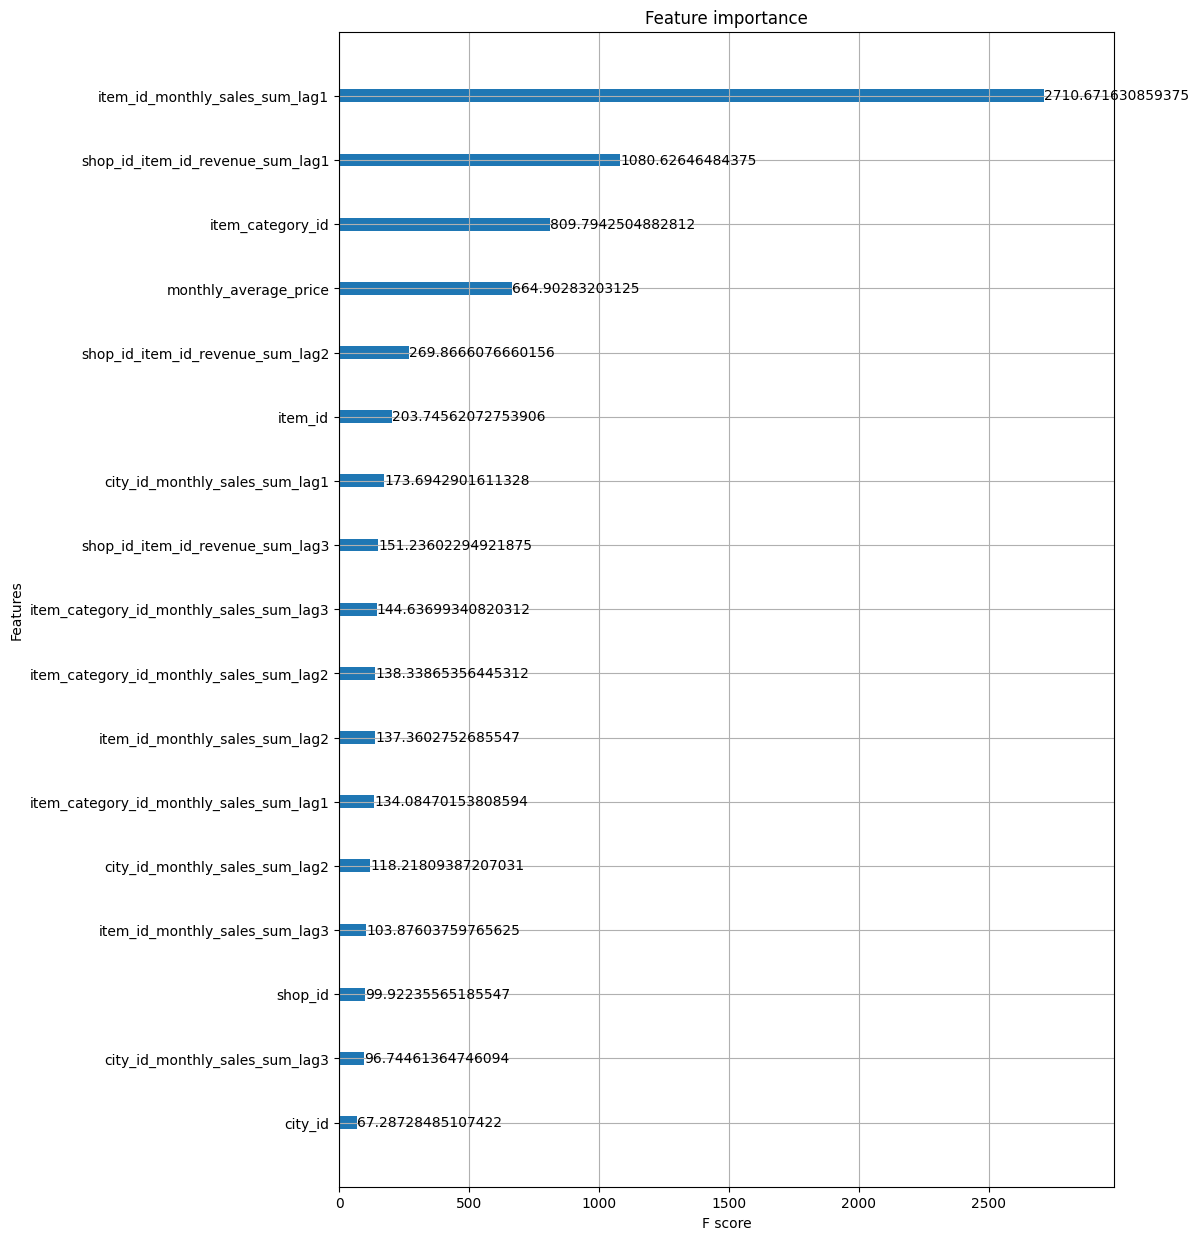

In [ ]:
fig, ax = plt.subplots(figsize = (10, 15))
xgb.plot_importance(model, importance_type = "gain", ax = ax);

<a id='prediction'></a>
### Prediction
[Volver al índice](#index)<br>

En este apartado vamos a utilizar el modelo entrenado para hacer una predicción y posteriormente enviar el submit a Kaggle.

In [ ]:
df.columns

Index(['date', 'city_id', 'shop_id', 'item_category_id', 'item_id',
       'monthly_average_price', 'monthly_sales',
       'item_id_monthly_sales_sum_lag1', 'item_id_monthly_sales_sum_lag2',
       'item_id_monthly_sales_sum_lag3', 'city_id_monthly_sales_sum_lag1',
       'city_id_monthly_sales_sum_lag2', 'city_id_monthly_sales_sum_lag3',
       'item_category_id_monthly_sales_sum_lag1',
       'item_category_id_monthly_sales_sum_lag2',
       'item_category_id_monthly_sales_sum_lag3',
       'shop_id_item_id_revenue_sum_lag1', 'shop_id_item_id_revenue_sum_lag2',
       'shop_id_item_id_revenue_sum_lag3'],
      dtype='object')

In [ ]:
X_test.info()
#del X_test['unique_id']

<class 'pandas.core.frame.DataFrame'>
Index: 426 entries, 12_11365 to 7_7893
Data columns (total 17 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   city_id                                  426 non-null    int64  
 1   shop_id                                  426 non-null    int64  
 2   item_category_id                         426 non-null    int64  
 3   item_id                                  426 non-null    int64  
 4   monthly_average_price                    426 non-null    float64
 5   item_id_monthly_sales_sum_lag1           426 non-null    float64
 6   item_id_monthly_sales_sum_lag2           426 non-null    float64
 7   item_id_monthly_sales_sum_lag3           426 non-null    float64
 8   city_id_monthly_sales_sum_lag1           426 non-null    float64
 9   city_id_monthly_sales_sum_lag2           426 non-null    float64
 10  city_id_monthly_sales_sum_lag3           426 

In [ ]:
if "monthly_sales" in X_test.columns:
    X_test.drop("monthly_sales", axis = 1, inplace = True)

Y_test_predict = model.predict(X_test,)
X_test["monthly_sales"] = Y_test_predict

In [ ]:
X_test.reset_index(inplace = True)

In [ ]:
Y_train_predict = model.predict(X_train)
Y_valida_predict = model.predict(X_valida)

rmse_train = np.sqrt(
    mean_squared_error(
        y_true = Y_train,
        y_pred = Y_train_predict
    )
)

rmse_valida = np.sqrt(
    mean_squared_error(
        y_true = Y_valida,
        y_pred = Y_valida_predict
    )
)

rmse_train= str(round(rmse_train, 3)).replace(".", "_")
rmse_valida = str(round(rmse_valida, 3)).replace(".", "_")

In [ ]:
print(f"Train RMSE: {rmse_train}")
print(f"Validation RMSE: {rmse_valida}")

Train RMSE: 2_65
Validation RMSE: 2_839


In [ ]:
(
    X_test[["unique_id", "monthly_sales"]]
    .to_csv(f"submission_train_{rmse_train}_valida_{rmse_valida}.csv", index = False)
)

[The importance of Benchmarking](https://blog.bigml.com/2020/03/20/machine-learning-benchmarking-youre-doing-it-wrong/)

[Tree Based Models and Extrapolation (MUY RECOMENDABLE)](https://shanminlin.medium.com/how-to-help-tree-based-models-extrapolate-7954287b1219)

[XGBoost](https://xgboost.readthedocs.io/en/stable/)

In [ ]:
df.to_csv('df_help.csv')